# Computer Vision 
## Notebook 1a — SimCLR Self-Supervised Pretraining on VisioDECT

| | |
|---|---|
| **Dataset** | **VisioDECT** (Part A cleaned image set, 20,603 images, labels **discarded** for SSL) |
| **SSL method** | **SimCLR** — contrastive NT-Xent agreement between two augmented views |
| **Encoder** | Backbone of **YOLOv26-s** — the Part A winner by test mAP50-95 (0.6489, 67.9 FPS) |
| **Framework** | `ssl-detection-lab` >= 0.8.1 (course package, github.com/rifat963/ssl-detection-lab) |
| **Downstream pair** | Notebook 1b loads this checkpoint and fine-tunes at the 20% label budget |

**Cover steps in order:** CONFIG → environment → leakage-safe 10/10/80
partition (printed + verified) → two-view augmentation demo → model definition + dry-run →
50-epoch pretraining with loss curve → representation diagnostics (t-SNE + nearest-neighbour
retrieval + a cross-scenario control + commentary) → checkpoint export with the §7 naming
convention and Kaggle-dataset hand-off.



## 0. How to Run This Notebook on Kaggle
1. **Create**: Kaggle → *Create* → *New Notebook* → File → Import Notebook.
2. **Settings**: Accelerator = **GPU T4 x2**; Internet = **On** (installs the course package from
   GitHub; nothing else is downloaded — pretraining starts from a randomly initialised YOLOv26-s
   backbone, as the assignment requires for SimCLR).
3. **Attach the Part A Notebook 1 output**: *Add Input → Your Work →* the committed Part A
   **Notebook 1 (EDA)** → its Output. `visiodect_yolo/` must appear under `/kaggle/input/...`.
   Part B merges its three splits and **re-partitions 10/10/80 with the shared seed** — the Part A
   splits themselves are not reused.
4. **Version gate (course announcement)**: the install cell must print
   `ssl-detection-lab version: 0.8.1` **or newer**. If an older version appears:
   *Run → Restart & clear cell outputs*, then run all again from the top.
5. **Run all.** The §6 timing probe (1 epoch) prints a 50-epoch estimate — proceed if it fits a
   single session; the documented fallback levers are in CONFIG.
6. **Commit** (*Save Version → Save & Run All*), set **Public**, then create a **public Kaggle
   dataset** from this notebook's output (e.g. `groupXX-partb-ssl-checkpoints`) — Notebook 1b
   attaches that dataset and loads `simclr_yolo26s_backbone.pt` from it (§9 prints the exact files).

> **Cross-check before you commit.** §3 prints the partition sizes and a fingerprint. They must
> match what Notebook 3a printed. If they don't, stop — the four-way comparison would be invalid.

## 1. CONFIG

In [ ]:
# =============================== CONFIG ===============================

# ---- method & encoder --------------------------------------------------
SSL_METHOD  = "simclr"
YOLO_ARCH   = "yolo26s.yaml"   # ARCHITECTURE ONLY (random init): the Part A winner was
                               # YOLOv26-s. MUST be the identical string used in 3a --
                               # a different architecture makes the backbones incomparable.
# Integration route (assignment "Backbone Integration Strategy"): SimCLR is a CNN method, so
# the assignment's prescribed route applies directly -- the NT-Xent objective is run on the
# YOLOv26-s CNN backbone itself, and the weights load layer-for-layer into the detector in 1b.
# No ViT adapter and no distillation step is needed (that choice only arises for I-JEPA/DINOv3).

# ---- Part B shared partition protocol (COPIED FROM 3a -- DO NOT EDIT) ---
PARTB_SEED   = 445    # ONE seed shared by ALL Part B notebooks: it fixes the
                      # 10/10/80 partition AND the nested label-fraction ranks.
TEST_FRAC    = 0.10
VAL_FRAC     = 0.10   # remaining 80% = SSL pool (labels discarded)

# ---- pretraining budget (COPIED FROM 3a -- DO NOT EDIT) ----------------
FAST_RUN     = False  # True = smoke preset for pipeline checks only
EPOCHS       = 35     # matches 3a. The assignment's standard is 30; 3a ran 50, and §2's
                      # fair-comparison rule makes CONSISTENCY across methods binding --
                      # so all four methods run 50 and the deviation is documented once
                      # in the report's §2 (Experimental Setup).
IMAGE_SIZE   = 224    # matches 3a exactly. Reduced from detection's 640 deliberately:
                      # SSL learns features, not boxes.
WORKERS      = 4
LR, MIN_LR   = 3e-4, 3e-6      # cosine decay inside the package -- matches 3a
WEIGHT_DECAY = 1e-4            # matches 3a
WARMUP_EPOCHS = 2              # matches 3a
GRAD_CLIP    = 5.0             # matches 3a
AMP          = True            # matches 3a

# ---- the two values that legitimately differ from 3a -------------------
BATCH_SIZE   = 128    # per GPU. 3a used 16, which is correct for I-JEPA and WRONG for SimCLR:
                      # NT-Xent's negatives are the other samples in the batch, and the course
                      # package computes the loss PER PROCESS with no cross-GPU all_gather
                      # (verified in ssldet/methods/simclr.py). At batch 16 each anchor would
                      # see 2*16-2 = 30 negatives; at 128 it sees 254. Memory at 224px with two
                      # views is ~5 GB of the T4's 15 GB, so this is free. Raise to 160 if the
                      # probe reports headroom; drop to 96 on any CUDA OOM.
GRAD_ACCUM   = 1      # 3a used 2. Accumulation CANNOT be used to enlarge a contrastive batch:
                      # each micro-batch computes its own softmax over its own negatives, so
                      # accumulating only averages gradients -- it does not add negatives.
                      # Claiming an "effective batch" of 256 here would be false. (Viva §4.3 Q4.)

# ---- SimCLR objective / heads (package defaults, stated explicitly) ----
TEMPERATURE       = 0.2    # NT-Xent tau (package default; see viva Q2 in §10)
PROJECTION_DIM    = 256    # matches 3a's projection width
HIDDEN_DIM        = 1024   # projection-head hidden width (package default)

# ---- probe & paths -------------------------------------------------------
TIMING_PROBE = True   # 1-epoch probe before the full run (Part A discipline)
NB1_DIR_MANUAL = None # e.g. Path("/kaggle/input/<nb1-slug>/visiodect_yolo")
WORK_ROOT   = "/kaggle/working"
SSL_POOL_DIR = f"{WORK_ROOT}/ssl_pool"             # symlinked 80% images
OUTPUT_DIR   = f"{WORK_ROOT}/simclr_yolo26s_visiodect"
PROBE_DIR    = f"{WORK_ROOT}/simclr_probe"
PARTITION_CSV = f"{WORK_ROOT}/partB_partition.csv" # shared by 1b/all notebooks
CKPT_BACKBONE = f"{WORK_ROOT}/simclr_backbone.pt"          # §7 naming convention
CKPT_YOLO     = f"{WORK_ROOT}/simclr_yolo26s_backbone.pt"  # YOLO-format copy for 1b

if FAST_RUN:   # smoke preset -- never commit with this on
    EPOCHS, IMAGE_SIZE, BATCH_SIZE, GRAD_ACCUM = 2, 160, 32, 1
    PROJECTION_DIM, HIDDEN_DIM = 128, 512

print(f"CONFIG | {SSL_METHOD} on {YOLO_ARCH} | {EPOCHS} epochs @ {IMAGE_SIZE}px "
      f"| batch {BATCH_SIZE}x{GRAD_ACCUM}/GPU | tau {TEMPERATURE} | seed {PARTB_SEED} "
      f"| checkpoint -> {CKPT_BACKBONE}")
print(f"negatives per anchor (per process) = 2*{BATCH_SIZE}-2 = {2*BATCH_SIZE-2}")

CONFIG | simclr on yolo26s.yaml | 35 epochs @ 224px | batch 128x1/GPU | tau 0.2 | seed 445 | checkpoint -> /kaggle/working/simclr_backbone.pt
negatives per anchor (per process) = 2*128-2 = 254


## 2. Environment — install the course package and gate the version

In [2]:
%pip install -q --no-cache-dir --force-reinstall --no-deps "git+https://github.com/rifat963/ssl-detection-lab.git@main" ultralytics

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
from dataclasses import replace
from importlib.metadata import version as installed_version
import json, random, shutil, time, os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import torch
import torch.nn.functional as F
from PIL import Image
from packaging.version import Version
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import v2
from tqdm.auto import tqdm
from ultralytics import YOLO

_v = installed_version("ssl-detection-lab")
print(f"ssl-detection-lab version: {_v}")
assert Version(_v) >= Version("0.8.1"), (
    "Older ssl-detection-lab detected. Per the course announcement: restart the "
    "session (Run -> Restart & clear cell outputs) and rerun the install cell first.")

import ssldet
from ssldet import PretrainConfig, launch_distributed_pretrain
from ssldet.backbones import YOLOBackboneEncoder
from ssldet.data import IMAGENET_MEAN, IMAGENET_STD, UnlabeledImageDataset, build_transform
from ssldet.ssl import create_ssl_module, available_ssl_modules

random.seed(PARTB_SEED); np.random.seed(PARTB_SEED)
torch.manual_seed(PARTB_SEED); torch.cuda.manual_seed_all(PARTB_SEED)
torch.set_float32_matmul_precision("high")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

GPU_COUNT = max(1, torch.cuda.device_count())
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(pd.Series({"ssl-detection-lab": ssldet.__version__, "PyTorch": torch.__version__,
                 "GPUs": GPU_COUNT if torch.cuda.is_available() else "CPU (smoke only)"}))
assert SSL_METHOD in available_ssl_modules(), \
    f"{SSL_METHOD!r} not registered; available: {available_ssl_modules()}"
print(f"[OK] '{SSL_METHOD}' is a registered objective in the course package")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ssl-detection-lab version: 0.9.0
ssl-detection-lab           0.9.0
PyTorch              2.10.0+cu128
GPUs                            2
dtype: object
[OK] 'simclr' is a registered objective in the course package


## 3. Leakage-Safe 10/10/80 Partition (shared by every SSL notebook)
The Part A splits are **not reused**: all 20,603 cleaned images are merged and re-partitioned
once, at image level, with the shared seed — 10% test holdout, 10% validation, 80% SSL pool.
This cell **prints the partition sizes** and **verifies by filename intersection** that test and
validation are disjoint from the SSL pool (both are assignment mandates). It also assigns every
pool image a seeded `pool_rank`, so the 20% fine-tuning subset (Notebook 1b) and the bonus
10–50% budgets are **nested by construction** — budget ρ is simply `pool_rank < ρ·|D|`.

**This code is byte-identical to Notebook 3a's partition cell.** Same seed, same shuffle
(`random.Random(PARTB_SEED).shuffle`), same rounding, same iteration order over a `sorted()` file
list. Identical inputs therefore give an identical split, which is what the fingerprint at the
bottom proves.

**Why this is not leakage :** SSL pretraining never reads annotations, so no label
information can leak; fine-tuning images legitimately overlap the SSL pool (the standard
SimCLR/BYOL label-efficiency protocol — this is literally the protocol from the SimCLR paper);
leakage would require test/val pixels in the pool, labels influencing pretraining, or test-driven
tuning — the checks below rule out the first and the pipeline never does the other two.

In [4]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def find_nb1_root():
    if NB1_DIR_MANUAL is not None:
        p = Path(NB1_DIR_MANUAL)
        if (p / "train" / "images").exists():
            return p
        raise FileNotFoundError(f"Manual path is not the NB1 output: {p}")
    base, stack = Path("/kaggle/input"), []
    stack.append((base, 0))
    while stack:
        d, dep = stack.pop()
        if d.name == "visiodect_yolo" and (d / "train" / "images").exists():
            return d
        if dep < 4:
            try:
                stack += [(c, dep + 1) for c in d.iterdir() if c.is_dir()]
            except (PermissionError, OSError):
                pass
    raise FileNotFoundError("Attach Part A Notebook 1's OUTPUT (visiodect_yolo/) as input.")

NB1_ROOT = find_nb1_root()
all_images = sorted(p for s in ("train", "val", "test")
                    for p in (NB1_ROOT / s / "images").rglob("*")
                    if p.is_file() and p.suffix.lower() in IMG_EXTS)
N = len(all_images)
print(f"NB1 root: {NB1_ROOT}\nMerged Part A images: {N:,}")

# ---- one seeded shuffle drives everything -----------------------------------
names = [p.name for p in all_images]
assert len(set(names)) == N, "filename collision across NB1 splits!"
order = list(range(N))
random.Random(PARTB_SEED).shuffle(order)
n_test, n_val = round(TEST_FRAC * N), round(VAL_FRAC * N)
test_idx = set(order[:n_test])
val_idx  = set(order[n_test:n_test + n_val])
pool_pos = order[n_test + n_val:]                 # shuffled order -> nested budgets

rows, pool_rank = [], {i: r for r, i in enumerate(pool_pos)}
for i, p in enumerate(all_images):
    part = "test" if i in test_idx else "val" if i in val_idx else "ssl_pool"
    rows.append({"filename": p.name, "source_path": str(p), "partition": part,
                 "pool_rank": pool_rank.get(i, -1)})
partition = pd.DataFrame(rows)
partition.to_csv(PARTITION_CSV, index=False)

sizes = partition.partition.value_counts()
print(f"\nPartition sizes (seed {PARTB_SEED}):")
print(sizes.to_string())
print(f"20% fine-tune budget for 1b = pool_rank < {round(0.20 * N):,} "
      f"(nested; bonus budgets use the same ranks)")

# ---- mandated disjointness verification (filename intersections) ------------
sets = {k: set(partition[partition.partition == k].filename)
        for k in ("test", "val", "ssl_pool")}
assert not (sets["test"] & sets["ssl_pool"]), "TEST leaked into SSL pool!"
assert not (sets["val"]  & sets["ssl_pool"]), "VAL leaked into SSL pool!"
assert not (sets["test"] & sets["val"]),      "TEST/VAL overlap!"
assert sum(map(len, sets.values())) == N
print("\n[OK] Disjointness verified by filename intersection: "
      "test ∩ pool = 0, val ∩ pool = 0, test ∩ val = 0")

NB1 root: /kaggle/input/notebooks/mahmudurrahman00627/cse445notebook1-eda-n1/visiodect_yolo
Merged Part A images: 20,603

Partition sizes (seed 445):
partition
ssl_pool    16483
test         2060
val          2060
20% fine-tune budget for 1b = pool_rank < 4,121 (nested; bonus budgets use the same ranks)

[OK] Disjointness verified by filename intersection: test ∩ pool = 0, val ∩ pool = 0, test ∩ val = 0


In [5]:
# ---- partition fingerprint: the cross-notebook equality check ---------------
import hashlib
FINGERPRINT = hashlib.md5(
    "|".join(f"{r.filename}:{r.partition}"
             for r in partition.sort_values("filename").itertuples()).encode()
).hexdigest()[:16]
print(f"[checksum] partition fingerprint = {FINGERPRINT}")
print("           Notebooks 2a/3a/4a and 1b-4b MUST print this same value.")
print("           If 3a's committed run shows a different value, the image set changed --")
print("           stop and reconcile before using either checkpoint.")

[checksum] partition fingerprint = 75e9c05d747bd9ec
           Notebooks 2a/3a/4a and 1b-4b MUST print this same value.
           If 3a's committed run shows a different value, the image set changed --
           stop and reconcile before using either checkpoint.


In [6]:
# ---- materialise the SSL pool as a directory (labels never copied) ----------
pool_dir = Path(SSL_POOL_DIR)
if pool_dir.exists():
    shutil.rmtree(pool_dir)
pool_dir.mkdir(parents=True)
for _, r in tqdm(partition[partition.partition == "ssl_pool"].iterrows(),
                 total=len(sets["ssl_pool"]), desc="linking SSL pool"):
    dst = pool_dir / r.filename
    try:
        os.symlink(r.source_path, dst)
    except OSError:
        shutil.copy2(r.source_path, dst)

pool_images = sorted(p for p in pool_dir.iterdir() if p.suffix.lower() in IMG_EXTS)
assert len(pool_images) == len(sets["ssl_pool"])
print(f"SSL pool directory ready: {len(pool_images):,} images "
      "(image files only — no label file is ever read in this notebook)")

linking SSL pool:   0%|          | 0/16483 [00:00<?, ?it/s]

SSL pool directory ready: 16,483 images (image files only — no label file is ever read in this notebook)


## 4. Method-Specific Views — the Two-View Augmentation Demo 
SimCLR's entire learning signal is **augmentation invariance** (viva Q1/Q5): two independently
augmented views of one image form the **positive pair**, and every other image in the batch
supplies the **negatives**. Without negatives the loss would be minimised by a constant output —
that is the collapse mode BYOL avoids structurally instead (viva Q1).

The course package builds the view pipeline in `ssldet.data.build_transform`, which for the
contrastive methods returns `TwoViews(strong_transform)`:
`RandomResizedCrop(scale=(0.30, 1.0))` → horizontal flip → `ColorJitter(0.35, 0.35, 0.35, 0.06)`
at p=0.8 → grayscale at p=0.10 → Gaussian blur at p=0.50 → normalise.

Note the crop scale: **0.30, not the SimCLR paper's 0.08**. This matters for VisioDECT
specifically and is worth raising unprompted at the viva — drones occupy a small fraction of the
frame, so an 8%-area crop frequently contains only sky, making the "positive pair" two patches of
empty background. The package's floor of 0.30 already mitigates this; §8.2 below tests whether
any residual background-matching effect survives into the learned representation.

In [7]:
ssl_config = PretrainConfig(
    method=SSL_METHOD,
    image_roots=[str(SSL_POOL_DIR)],          # the 80% pool ONLY (verified above)
    output_dir=str(OUTPUT_DIR),
    yolo_model=YOLO_ARCH,
    epochs=EPOCHS, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE,
    workers=WORKERS, max_images=None, seed=PARTB_SEED,
    learning_rate=LR, min_learning_rate=MIN_LR, weight_decay=WEIGHT_DECAY,
    warmup_epochs=WARMUP_EPOCHS, grad_accum_steps=GRAD_ACCUM,
    gradient_clip=GRAD_CLIP, amp=AMP,
    projection_dim=PROJECTION_DIM, hidden_dim=HIDDEN_DIM,
    temperature=TEMPERATURE,
    save_every=1,
).validate()
print("PretrainConfig validated | two-view contrastive objective |",
      f"tau = {ssl_config.temperature} | projection {HIDDEN_DIM} -> {PROJECTION_DIM}")

PretrainConfig validated | two-view contrastive objective | tau = 0.2 | projection 1024 -> 256


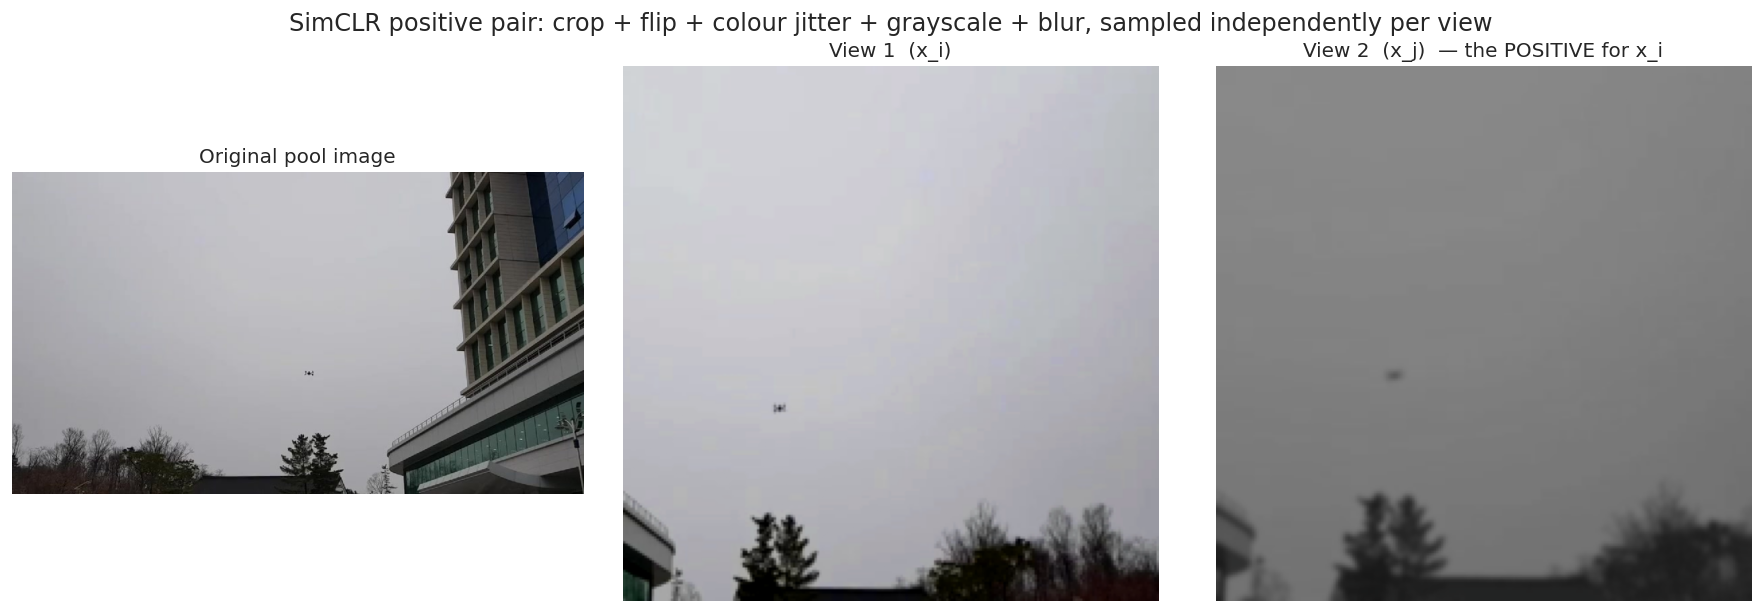

During training these two views are pulled together by NT-Xent, while the other 254 views in the process's batch are pushed apart as negatives.


In [8]:
# ---- single-image demo: the two augmented views that form a positive pair ----
preview_dataset = UnlabeledImageDataset(pool_images, build_transform(ssl_config))
view_one, view_two = preview_dataset[0]
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def show(t):
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0)

with Image.open(pool_images[0]) as im:
    original = im.convert("RGB")

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
axes[0].imshow(original);        axes[0].set_title("Original pool image")
axes[1].imshow(show(view_one));  axes[1].set_title("View 1  (x_i)")
axes[2].imshow(show(view_two));  axes[2].set_title("View 2  (x_j)  — the POSITIVE for x_i")
for ax in axes:
    ax.axis("off")
plt.suptitle("SimCLR positive pair: crop + flip + colour jitter + grayscale + blur, "
             "sampled independently per view")
plt.tight_layout()
plt.savefig(f"{WORK_ROOT}/simclr_views.png", dpi=150, bbox_inches="tight")
plt.show()
print("During training these two views are pulled together by NT-Xent, while the other "
      f"{2*BATCH_SIZE-2} views in the process's batch are pushed apart as negatives.")

## 5. Model Definition + Dry Run 
Encoder = the **YOLOv26-s backbone** (randomly initialised — the assignment requires running the
SimCLR objective ourselves), globally average-pooled to a feature vector; plus a 2-layer
**projection head** (`feature_dim → 1024 → 256`) whose output is L2-normalised before the NT-Xent
loss. There is no target network and no EMA — that asymmetry is BYOL's mechanism, not SimCLR's.

The **projection head is discarded after pretraining** (viva Q3): it is optimised to be invariant
to exactly the augmentations above, including colour and scale, and a drone detector needs those
cues. The backbone one layer earlier retains them, so the backbone is what transfers to 1b.

One forward pass prints the pooled feature width and an untrained example loss — proof the
objective is wired before any GPU-hours are spent. Expect the untrained loss to be **at or above**
the `ln(2N-1)` chance line: an untrained encoder has no reason to align a positive pair, and its
random projections routinely place two views of one image further apart than two different images.
The number that matters is the *trained* loss in §7.1 falling clearly below chance at N = 128.

In [9]:
import math
probe_detector = YOLO(ssl_config.yolo_model)
probe_encoder  = YOLOBackboneEncoder(probe_detector.model).to(DEVICE)
feature_channels, gh, gw = probe_encoder.infer_dimensions(ssl_config.image_size, DEVICE)
with torch.no_grad():
    feature_dim = int(probe_encoder(torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE,
                                                device=DEVICE)).shape[1])

simclr_module = create_ssl_module(
    SSL_METHOD, encoder=probe_encoder,
    feature_dim=feature_dim,
    hidden_dim=ssl_config.hidden_dim,
    projection_dim=ssl_config.projection_dim,
    temperature=ssl_config.temperature,
).to(DEVICE)

# NT-Xent needs >= 2 samples per process: feed a 4-image micro-batch of real views.
dry = [preview_dataset[i] for i in range(4)]
batch = (torch.stack([d[0] for d in dry]).to(DEVICE),
         torch.stack([d[1] for d in dry]).to(DEVICE))
amp_ctx = torch.amp.autocast("cuda") if DEVICE.type == "cuda" else torch.amp.autocast("cpu", enabled=False)
with torch.inference_mode(), amp_ctx:
    example_loss = simclr_module(batch)

print(pd.Series({
    "encoder": f"YOLOv26-s backbone ({sum(p.numel() for p in probe_encoder.parameters())/1e6:.1f} M params)",
    "backbone feature map": f"{feature_channels} x {gh} x {gw} @ {IMAGE_SIZE}px",
    "pooled feature dim": feature_dim,
    "projection head": f"{feature_dim} -> {ssl_config.hidden_dim} -> {ssl_config.projection_dim}",
    "untrained example loss": round(float(example_loss), 4),
    "chance level ln(2N-1), N=4": round(math.log(2 * 4 - 1), 4),
    "note": "untrained loss >= chance is normal; see the markdown above",
}))
del simclr_module, probe_encoder, probe_detector, example_loss, dry, batch
torch.cuda.empty_cache()

encoder                                       YOLOv26-s backbone (5.4 M params)
backbone feature map                                        512 x 7 x 7 @ 224px
pooled feature dim                                                          512
projection head                                              512 -> 1024 -> 256
untrained example loss                                                   2.4178
chance level ln(2N-1), N=4                                               1.9459
note                          untrained loss >= chance is normal; see the ma...
dtype: object


## 6. 1-Epoch Timing Probe 
The assignment requires the run to fit one T4 session and allows documented budget levers
(resolution, AMP, batch size). This probe measures one real epoch through the launcher and
extrapolates ×`EPOCHS` — the same measure-before-commit protocol that saved Part A twice.

In [10]:
if TIMING_PROBE:
    probe_cfg = replace(ssl_config, epochs=1, warmup_epochs=0,
                        output_dir=str(PROBE_DIR)).validate()
    t0 = time.time()
    launch_distributed_pretrain(probe_cfg, num_processes=GPU_COUNT,
                                config_path=Path(PROBE_DIR) / "probe_config.yaml", check=True)
    probe_min = (time.time() - t0) / 60
    est = probe_min * EPOCHS
    print(f"\nProbe epoch: {probe_min:.1f} min -> {EPOCHS}-epoch estimate: "
          f"{est:.0f} min ({est/60:.1f} h)")
    print("[OK] Fits a single session." if est <= 9 * 60 else
          "[!] OVER BUDGET — documented levers, in order: BATCH_SIZE 128 -> 96 only if OOM "
          "(never for speed: it costs negatives), IMAGE_SIZE 224 -> 192, then an epoch "
          "reduction applied identically to ALL four SSL methods (assignment rule).")
    shutil.rmtree(PROBE_DIR, ignore_errors=True)
else:
    print("Timing probe skipped (TIMING_PROBE=False).")

SIMCLR 01/01:   0%|          | 0/64 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/ssldet/trainer.py:230: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
/usr/local/lib/python3.12/dist-packages/ssldet/trainer.py:230: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
SIMC

Epoch 01 | loss=4.38138 | time=280.0s


/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


{
  "output_dir": "/kaggle/working/simclr_probe",
  "yolo_checkpoint": "/kaggle/working/simclr_probe/simclr_pretrained_yolo26s.pt",
  "ssl_checkpoint": "/kaggle/working/simclr_probe/last_ssl.pt",
  "history_csv": "/kaggle/working/simclr_probe/history.csv",
  "manifest_json": "/kaggle/working/simclr_probe/run_manifest.json"
}
{
  "output_dir": "/kaggle/working/simclr_probe",
  "yolo_checkpoint": "/kaggle/working/simclr_probe/simclr_pretrained_yolo26s.pt",
  "ssl_checkpoint": "/kaggle/working/simclr_probe/last_ssl.pt",
  "history_csv": "/kaggle/working/simclr_probe/history.csv",
  "manifest_json": "/kaggle/working/simclr_probe/run_manifest.json"
}

Probe epoch: 5.1 min -> 35-epoch estimate: 177 min (3.0 h)
[OK] Fits a single session.


## 7. Full Pretraining 
`launch_distributed_pretrain` spawns one process per GPU (T4 x2) via `torch.distributed.run`;
loss is logged per epoch to `history.csv`. **No label file is opened anywhere in this run** — the
dataset class reads pixels only.

One honesty note for the report: the NT-Xent loss is computed **per process**, so with two GPUs
each anchor sees the negatives from its own 128-image shard, not all 256. The reported negative
count is 254, not 510.

In [11]:
t0 = time.time()
training_result = launch_distributed_pretrain(
    ssl_config, num_processes=GPU_COUNT,
    config_path=Path(OUTPUT_DIR) / "simclr_config.yaml", check=True)
TRAIN_MINUTES = (time.time() - t0) / 60
print(f"\nPretraining wall time: {TRAIN_MINUTES:.1f} min")
print(training_result)

SIMCLR 01/35:   0%|          | 0/64 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/ssldet/trainer.py:230: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
/usr/local/lib/python3.12/dist-packages/ssldet/trainer.py:230: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
SIMC

Epoch 01 | loss=4.87064 | time=280.2s


SIMCLR 02/35: 100%|██████████| 64/64 [04:15<00:00,  3.99s/it, ema=0.99603, loss=3.7632, lr=3.00e-04]


Epoch 02 | loss=3.76652 | time=255.4s


SIMCLR 03/35: 100%|██████████| 64/64 [04:33<00:00,  4.27s/it, ema=0.99607, loss=3.0901, lr=2.99e-04]


...

Epoch 34 | loss=1.76107 | time=287.4s


SIMCLR 35/35: 100%|██████████| 64/64 [04:54<00:00,  4.61s/it, ema=1.00000, loss=1.7675, lr=3.00e-06]


Epoch 35 | loss=1.75820 | time=294.9s


/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


{
  "output_dir": "/kaggle/working/simclr_yolo26s_visiodect",
  "yolo_checkpoint": "/kaggle/working/simclr_yolo26s_visiodect/simclr_pretrained_yolo26s.pt",
  "ssl_checkpoint": "/kaggle/working/simclr_yolo26s_visiodect/last_ssl.pt",
  "history_csv": "/kaggle/working/simclr_yolo26s_visiodect/history.csv",
  "manifest_json": "/kaggle/working/simclr_yolo26s_visiodect/run_manifest.json"
}
{
  "output_dir": "/kaggle/working/simclr_yolo26s_visiodect",
  "yolo_checkpoint": "/kaggle/working/simclr_yolo26s_visiodect/simclr_pretrained_yolo26s.pt",
  "ssl_checkpoint": "/kaggle/working/simclr_yolo26s_visiodect/last_ssl.pt",
  "history_csv": "/kaggle/working/simclr_yolo26s_visiodect/history.csv",
  "manifest_json": "/kaggle/working/simclr_yolo26s_visiodect/run_manifest.json"
}

Pretraining wall time: 168.8 min
DistributedPretrainResult(config_path=PosixPath('/kaggle/working/simclr_yolo26s_visiodect/simclr_config.yaml'), output_dir=PosixPath('/kaggle/working/simclr_yolo26s_visiodect'), command=('/usr

### 7.1 Loss Curve and Run Manifest 
The dashed line is the **chance level**, `ln(2N-1)` for N = `BATCH_SIZE`: the loss of an encoder
that cannot tell the positive from the negatives. How far below it the curve settles is the
quantitative statement of "did the objective actually learn", and it is the number to quote in
the report rather than the raw final loss (which is not comparable across methods with different
objectives).

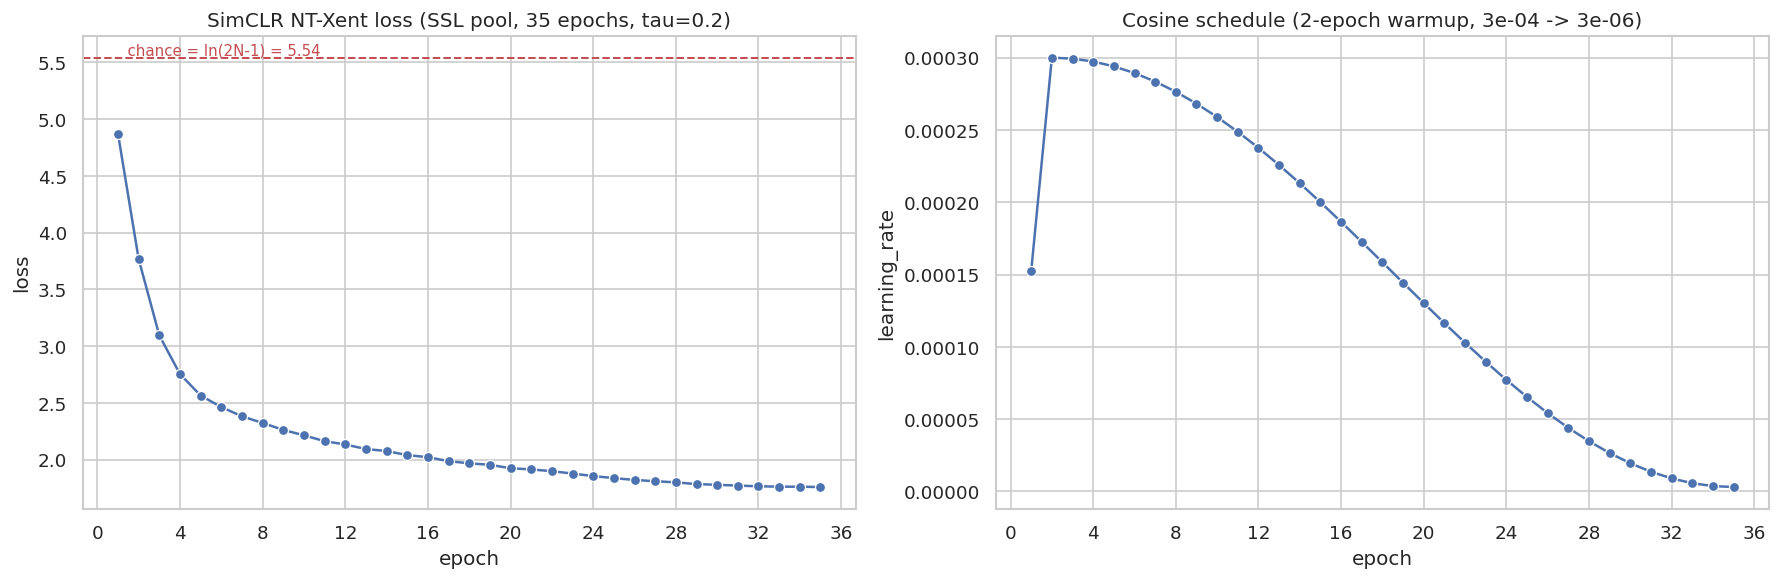

best SSL checkpoint                /kaggle/working/simclr_yolo26s_visiodect/best_...
YOLO-format backbone checkpoint    /kaggle/working/simclr_yolo26s_visiodect/simcl...
first-epoch loss                                                              4.8706
best loss                                                                     1.7582
chance level ln(2N-1)                                                         5.5413
margin below chance                                                           3.7831
unlabelled images seen                                                         16483
world size (GPUs)                                                                  2
dtype: object
[OK] trainer consumed exactly the verified 80% pool — nothing more, nothing less


In [12]:
history  = pd.read_csv(Path(OUTPUT_DIR) / "history.csv")
manifest = json.loads((Path(OUTPUT_DIR) / "run_manifest.json").read_text())
BEST_SSL = Path(OUTPUT_DIR) / "best_ssl.pt"
YOLO_CHECKPOINT = Path(manifest["outputs"]["yolo_checkpoint"])
CHANCE = math.log(2 * BATCH_SIZE - 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=history, x="epoch", y="loss", marker="o", ax=axes[0])
axes[0].axhline(CHANCE, ls="--", c="r", lw=1.2)
axes[0].text(history.epoch.min(), CHANCE, f"  chance = ln(2N-1) = {CHANCE:.2f}",
             va="bottom", color="r", fontsize=9)
axes[0].set_title(f"SimCLR NT-Xent loss (SSL pool, {EPOCHS} epochs, tau={TEMPERATURE})")
sns.lineplot(data=history, x="epoch", y="learning_rate", marker="o", ax=axes[1])
axes[1].set_title(f"Cosine schedule ({WARMUP_EPOCHS}-epoch warmup, {LR:.0e} -> {MIN_LR:.0e})")
for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(f"{WORK_ROOT}/simclr_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(pd.Series({
    "best SSL checkpoint": str(BEST_SSL),
    "YOLO-format backbone checkpoint": str(YOLO_CHECKPOINT),
    "first-epoch loss": round(float(history.loss.iloc[0]), 4),
    "best loss": round(float(manifest["best_loss"]), 4),
    "chance level ln(2N-1)": round(CHANCE, 4),
    "margin below chance": round(CHANCE - float(manifest["best_loss"]), 4),
    "unlabelled images seen": manifest["unlabeled_images"],
    "world size (GPUs)": manifest["world_size"],
}))
assert manifest["unlabeled_images"] == len(pool_images), \
    "trainer saw a different image count than the verified SSL pool!"
print("[OK] trainer consumed exactly the verified 80% pool — nothing more, nothing less")

## 8. Representation Diagnostics 
Embeddings are extracted for a **500-image sample of the validation partition** (never seen
during pretraining) with the trained backbone. VisioDECT's filenames encode
`Class_scenario_original`, so the t-SNE can be coloured two ways — by **drone class** (does the
representation organise target-class content?) and by **scenario** (or does it organise by
lighting instead — an equally honest finding). Labels are used here for **colouring diagnostics
only, after training** — pretraining never saw them.

This section is deliberately identical to 3a's §8 so the two methods' numbers are directly
comparable, with **one addition** in §8.2: a cross-scenario control, explained there.

In [13]:
SCENARIOS = ["cloudy", "evening", "sunny"]
CLASS_NAMES = ["Anafi", "DJI_FPV", "DJI_Phantom", "EFT_E410S", "Mavic_Air", "Mavic_Enterprise"]

def parse_stem(stem):
    for c in sorted(CLASS_NAMES, key=len, reverse=True):
        if stem.startswith(c + "_"):
            rest = stem[len(c) + 1:]
            scen = rest.split("_")[0]
            return c, scen if scen in SCENARIOS else "unknown"
    return "unknown", "unknown"

val_rows = partition[partition.partition == "val"]
sel = val_rows.sample(min(500, len(val_rows)), random_state=PARTB_SEED)
sel_paths  = [Path(p) for p in sel.source_path]
sel_class  = [parse_stem(Path(p).stem)[0] for p in sel.source_path]
sel_scen   = [parse_stem(Path(p).stem)[1] for p in sel.source_path]

n_unparsed = sum(1 for c in sel_class if c == "unknown")
print(f"filename parse: {len(sel_class) - n_unparsed}/{len(sel_class)} recognised"
      + ("" if n_unparsed == 0 else
         f"  [!] {n_unparsed} unparsed - CLASS_NAMES may not match this dataset build"))

feature_transform = v2.Compose([
    v2.Resize(ssl_config.image_size + 32, antialias=True),
    v2.CenterCrop(ssl_config.image_size),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

class FeatureDataset(Dataset):
    def __len__(self):
        return len(sel_paths)
    def __getitem__(self, i):
        with Image.open(sel_paths[i]) as im:
            return feature_transform(im.convert("RGB")), i

encoder = YOLOBackboneEncoder(YOLO(str(YOLO_CHECKPOINT)).model).to(DEVICE).eval()
loader = DataLoader(FeatureDataset(), batch_size=64, shuffle=False,
                    num_workers=min(2, WORKERS), pin_memory=DEVICE.type == "cuda")
feats = []
amp_ctx = torch.amp.autocast("cuda") if DEVICE.type == "cuda" else torch.amp.autocast("cpu", enabled=False)
with torch.inference_mode(), amp_ctx:
    for images, _ in tqdm(loader, desc="extracting SimCLR features (val sample)"):
        f = encoder(images.to(DEVICE, non_blocking=True))
        feats.append(F.normalize(f.float(), dim=1).cpu())
feature_matrix = torch.cat(feats)
print(f"features: {tuple(feature_matrix.shape)} | "
      f"mean per-dim std: {feature_matrix.std(dim=0).mean():.4f} "
      "(a healthy non-collapsed representation has clearly non-zero spread)")

filename parse: 500/500 recognised


extracting SimCLR features (val sample):   0%|          | 0/8 [00:00<?, ?it/s]

features: (500, 512) | mean per-dim std: 0.0418 (a healthy non-collapsed representation has clearly non-zero spread)


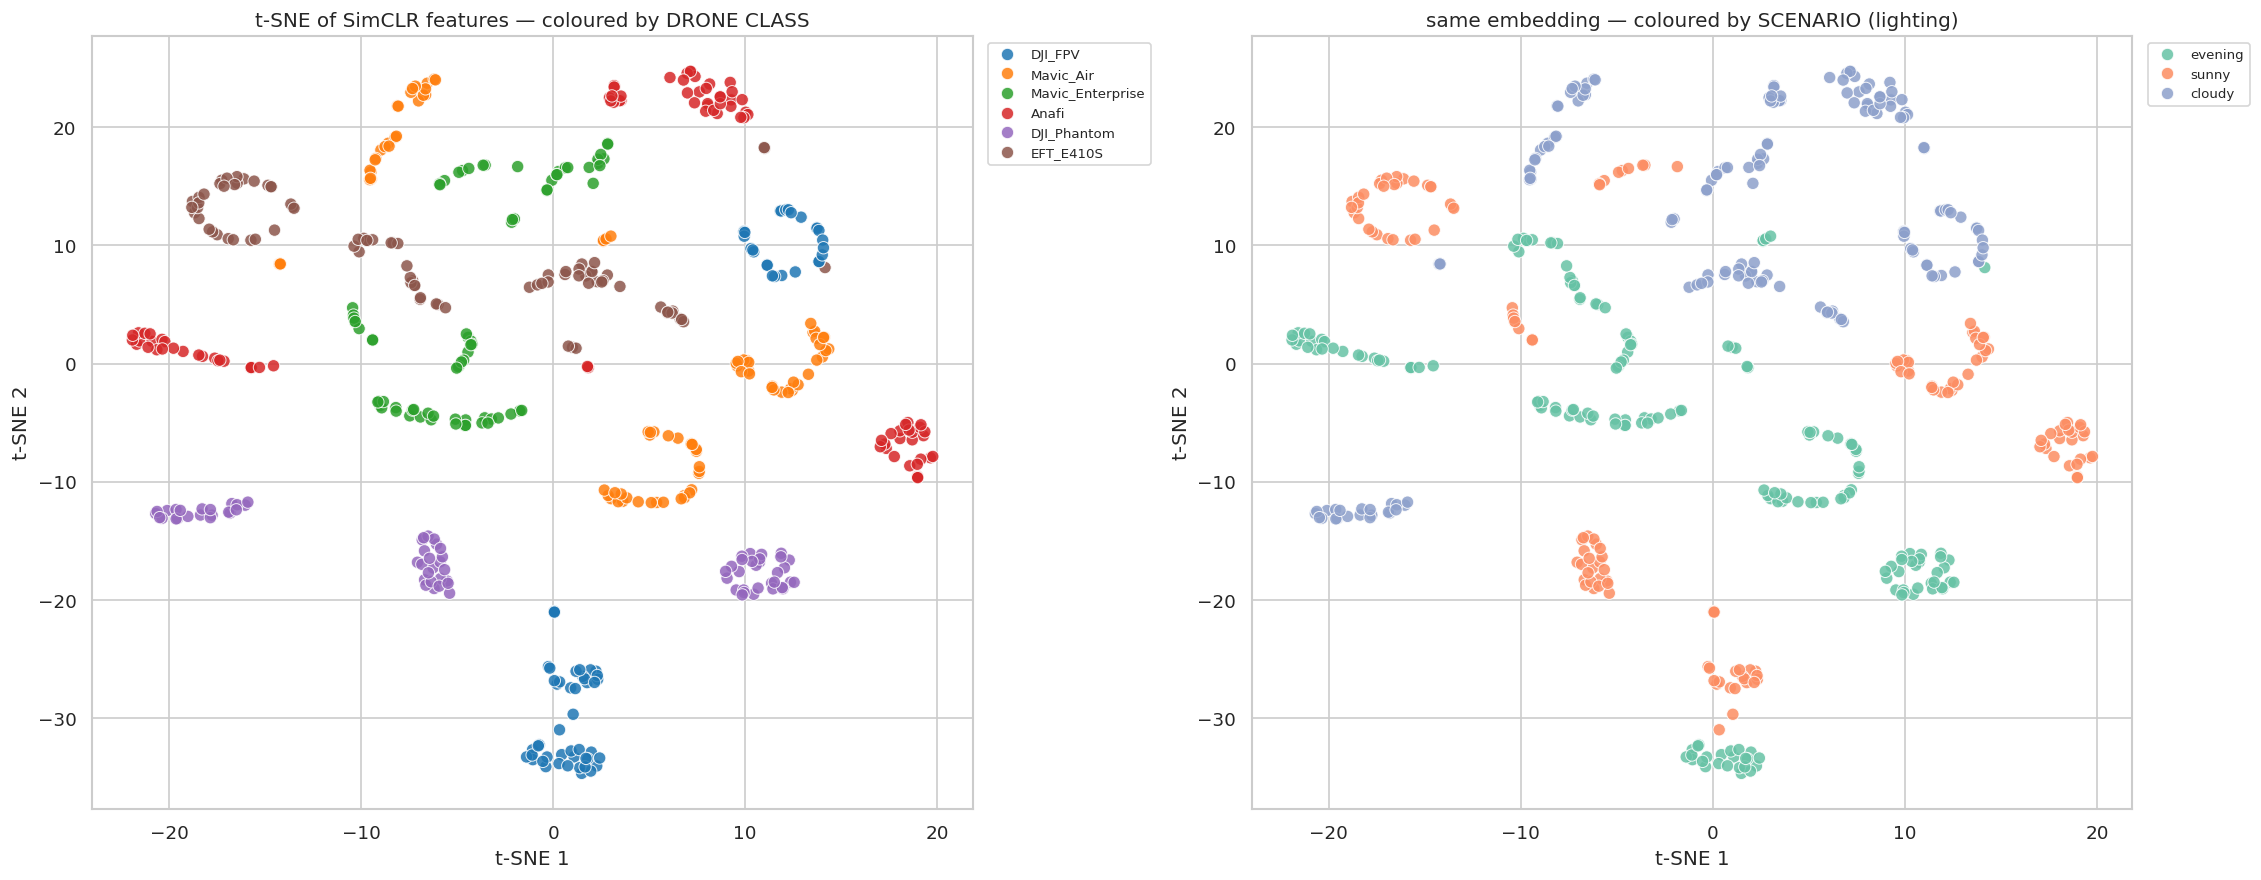

top-5 neighbour agreement — class: 98.3% (chance ~16.7%) | scenario: 98.8% (chance ~33.3%)


In [14]:
# ---- t-SNE coloured by class AND by scenario --------------------------------
perp = min(30.0, max(2.0, (len(feature_matrix) - 1) / 3))
coords = TSNE(n_components=2, perplexity=perp, learning_rate="auto",
              init="pca", max_iter=1000, random_state=PARTB_SEED
              ).fit_transform(feature_matrix.numpy())
frame = pd.DataFrame({"t-SNE 1": coords[:, 0], "t-SNE 2": coords[:, 1],
                      "class": sel_class, "scenario": sel_scen})
fig, axes = plt.subplots(1, 2, figsize=(19, 7.5))
sns.scatterplot(data=frame, x="t-SNE 1", y="t-SNE 2", hue="class",
                palette="tab10", s=55, alpha=0.85, ax=axes[0])
axes[0].set_title("t-SNE of SimCLR features — coloured by DRONE CLASS")
sns.scatterplot(data=frame, x="t-SNE 1", y="t-SNE 2", hue="scenario",
                palette="Set2", s=55, alpha=0.85, ax=axes[1])
axes[1].set_title("same embedding — coloured by SCENARIO (lighting)")
for ax in axes:
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{WORK_ROOT}/simclr_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

# quantitative check: do top-5 neighbours share the query's class?
sims = feature_matrix @ feature_matrix.T
sims.fill_diagonal_(-1)
top5 = sims.topk(5, dim=1).indices
agree = np.mean([[sel_class[j] == sel_class[i] for j in row.tolist()]
                 for i, row in enumerate(top5)])
scen_agree = np.mean([[sel_scen[j] == sel_scen[i] for j in row.tolist()]
                      for i, row in enumerate(top5)])
print(f"top-5 neighbour agreement — class: {agree:.1%} (chance ~16.7%) | "
      f"scenario: {scen_agree:.1%} (chance ~33.3%)")

### 8.1 Nearest-Neighbour Retrieval Panels

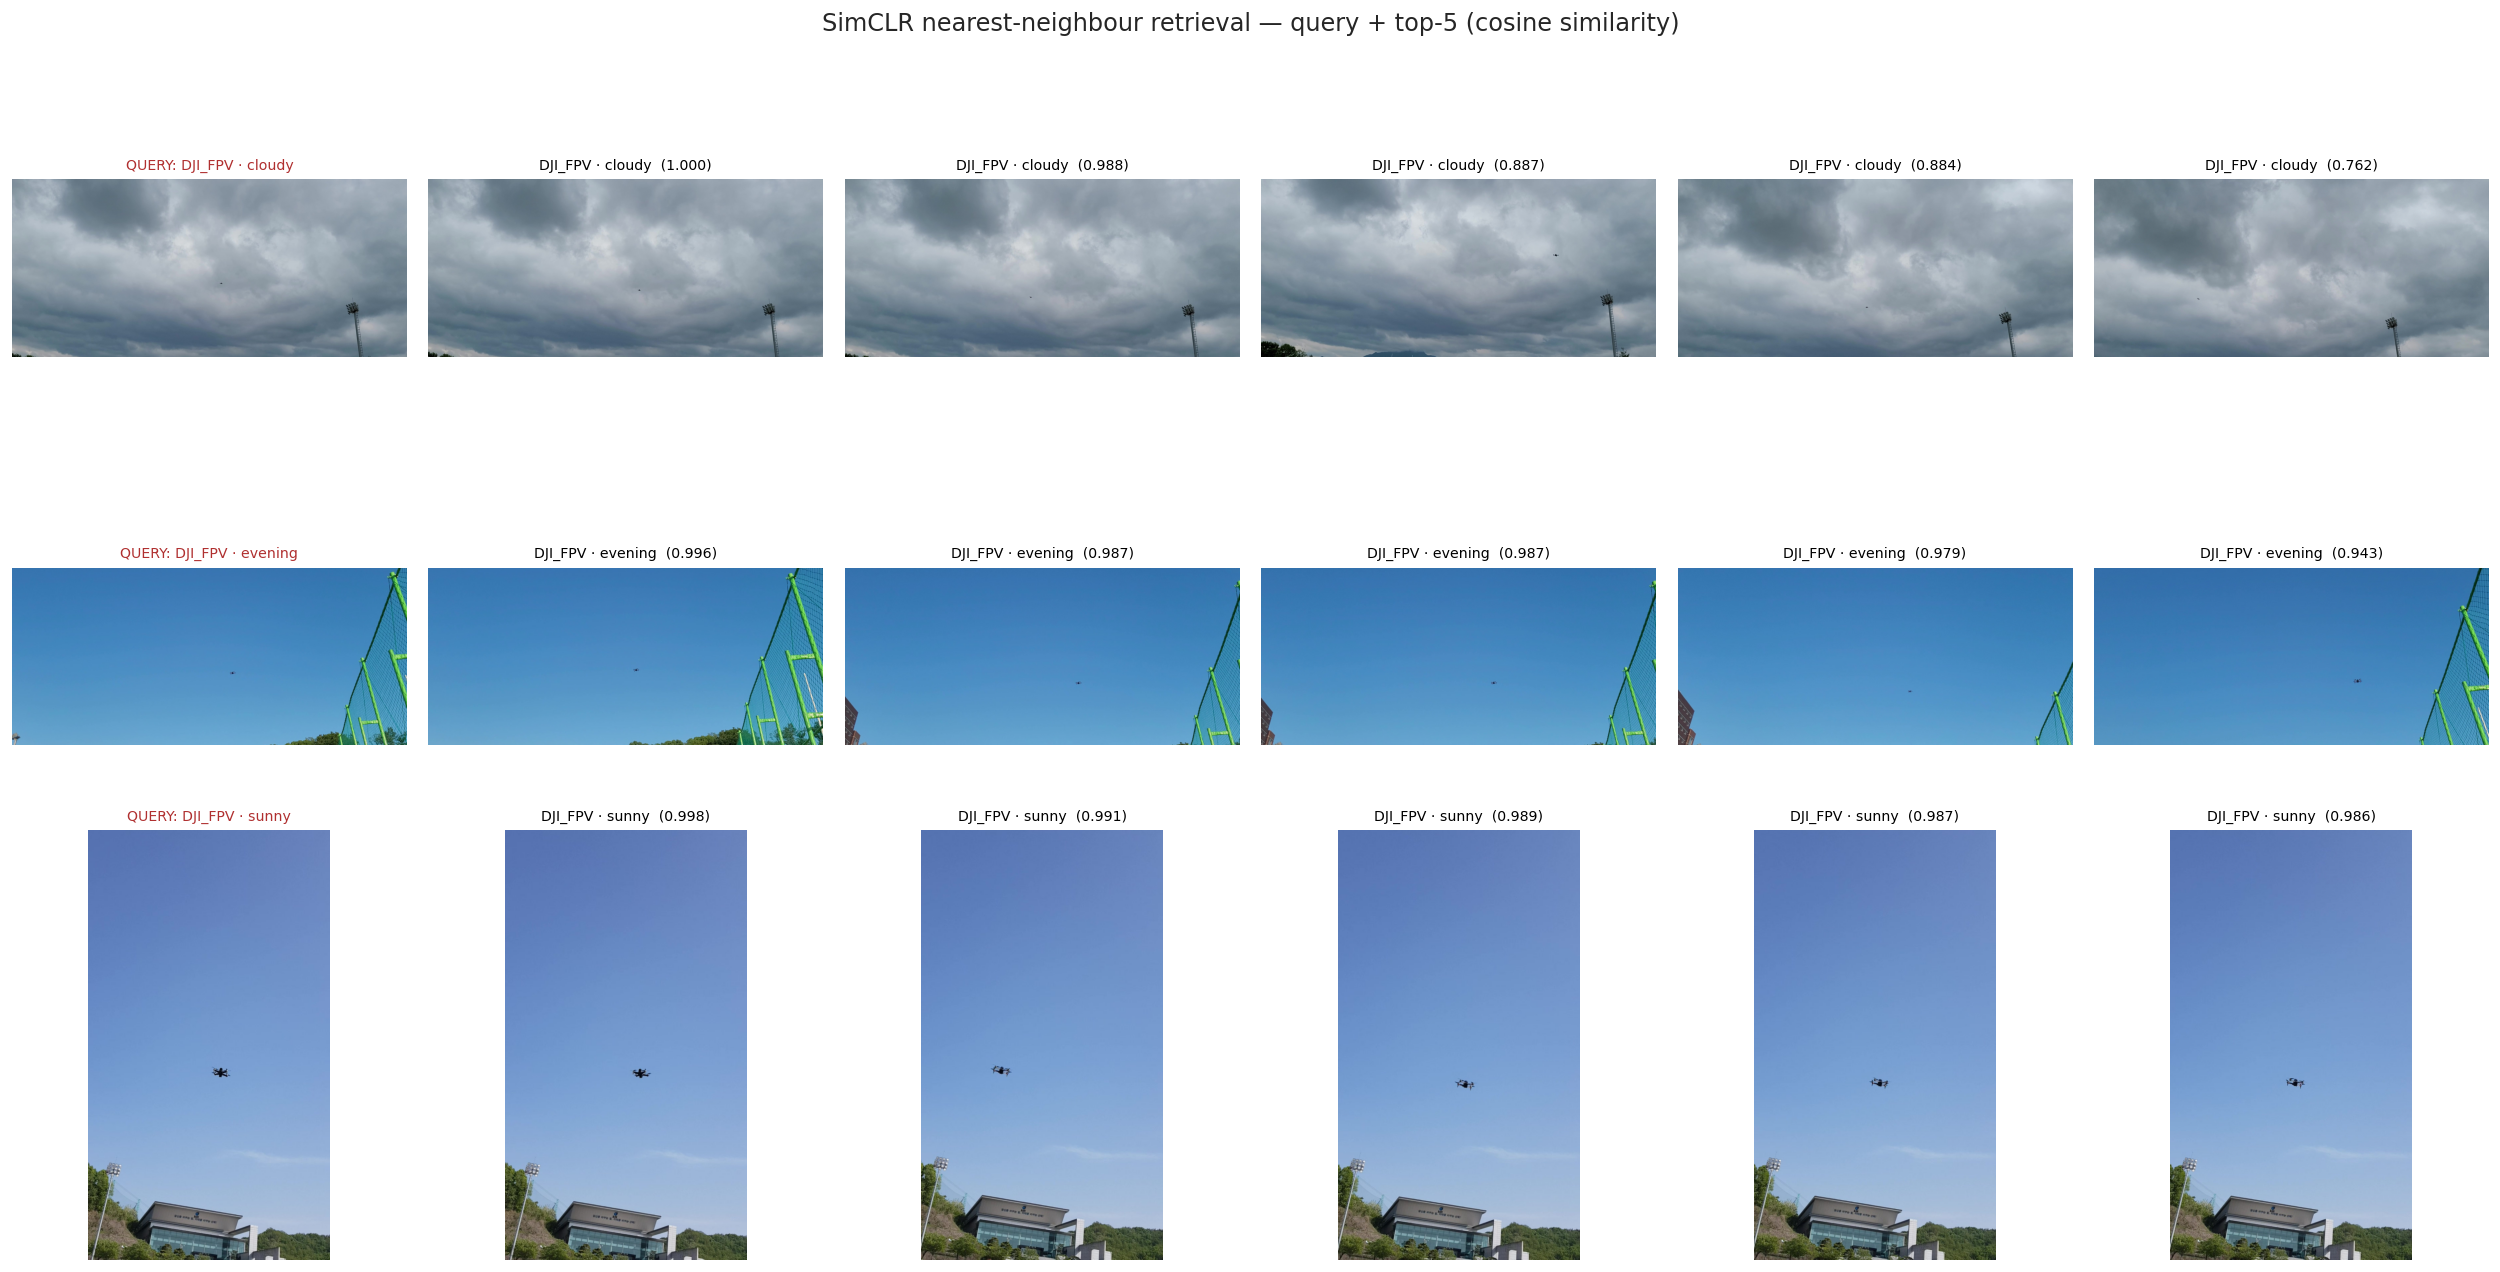

In [15]:
# ---- nearest-neighbour retrieval panels (one query per scenario) ------------
queries = [i for scen in SCENARIOS
           for i in [next((k for k, s in enumerate(sel_scen) if s == scen), None)]
           if i is not None] or [0]
fig, axes = plt.subplots(len(queries), 6, figsize=(21, 3.6 * len(queries)))
axes = np.atleast_2d(axes)
for row, q in enumerate(queries):
    nn = [j for j in sims[q].topk(6).indices.tolist() if j != q][:5]
    for col, idx in enumerate([q] + nn):
        ax = axes[row, col]
        with Image.open(sel_paths[idx]) as im:
            ax.imshow(im.convert("RGB"))
        ax.axis("off")
        ax.set_title("QUERY: " + f"{sel_class[idx]} · {sel_scen[idx]}" if col == 0
                     else f"{sel_class[idx]} · {sel_scen[idx]}  ({sims[q][idx]:.3f})",
                     fontsize=8.5, color="#b03030" if col == 0 else "black")
plt.suptitle("SimCLR nearest-neighbour retrieval — query + top-5 (cosine similarity)")
plt.tight_layout()
plt.savefig(f"{WORK_ROOT}/simclr_retrieval.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.2 Cross-Scenario Control — testing the alternative explanation

The raw agreement number above has an obvious competing explanation, and the assignment's report
§6 explicitly requires at least one claim to be tested against an alternative. Here it is:

> **Alternative explanation.** VisioDECT is shot as continuous clips, one drone model per clip per
> lighting condition. A validation frame's nearest neighbour is therefore very often *another
> frame of the same clip* — near-identical background, near-identical framing. High class
> agreement would then measure **clip recall**, not drone recognition, and an encoder that had
> learned nothing about drones would still score well.

The control below restricts each query's candidate neighbours to images from a **different
lighting scenario**. Same-clip frames are excluded by construction, because a clip has exactly
one scenario. Class agreement that survives this restriction cannot be explained by background
matching: the model must recognise the same drone model under different illumination.

Chance stays at 1/6 ≈ 16.7%. Report **both** numbers in §5.1 of the report and use the gap
between them in §6 — that gap is the finding, whichever way it falls.

In [16]:
sims_np = sims.numpy().copy()
scen_arr = np.array(sel_scen)
cls_arr = np.array(sel_class)
valid = (cls_arr != "unknown") & (scen_arr != "unknown")

raw_top1, ctl_top1, ctl_top5, n_ctl = [], [], [], 0
for i in range(len(sel_paths)):
    if not valid[i]:
        continue
    order = np.argsort(-sims_np[i])
    order = [j for j in order if j != i and valid[j]]
    if not order:
        continue
    raw_top1.append(cls_arr[order[0]] == cls_arr[i])
    cross = [j for j in order if scen_arr[j] != scen_arr[i]]
    if len(cross) >= 5:
        ctl_top1.append(cls_arr[cross[0]] == cls_arr[i])
        ctl_top5.append(np.mean([cls_arr[j] == cls_arr[i] for j in cross[:5]]))
        n_ctl += 1

raw_acc = float(np.mean(raw_top1))
ctl_acc = float(np.mean(ctl_top1)) if ctl_top1 else float("nan")
ctl_acc5 = float(np.mean(ctl_top5)) if ctl_top5 else float("nan")
CHANCE_CLS = 1.0 / len(set(cls_arr[valid]))

print(f"top-1 class agreement, unrestricted        : {raw_acc:.1%}  (n={len(raw_top1)})")
print(f"top-1 class agreement, CROSS-SCENARIO only : {ctl_acc:.1%}  (n={n_ctl})")
print(f"top-5 class agreement, CROSS-SCENARIO only : {ctl_acc5:.1%}")
print(f"chance level (1/{len(set(cls_arr[valid]))} classes)                 : {CHANCE_CLS:.1%}")

gap = raw_acc - ctl_acc
if gap > 0.15:
    verdict = ("A large share of the unrestricted agreement disappears once same-scenario "
               "neighbours are removed. Report the cross-scenario number as the honest measure: "
               "the representation is substantially organised by scene/lighting, not drone "
               "identity. Expect 1b's gain over random init to come from low-level filter "
               "quality rather than semantic separation.")
elif ctl_acc - CHANCE_CLS > 0.15:
    verdict = ("Agreement survives the cross-scenario restriction and stays well above chance: "
               "the encoder recognises the same drone model under different illumination, which "
               "is not explainable by background matching.")
else:
    verdict = ("Cross-scenario agreement sits near chance. At this budget SimCLR has learned "
               "scene statistics more than drone identity — a legitimate and reportable "
               "negative result, and a direct prediction that its 1b transfer will trail "
               "methods with stronger semantic structure.")
print("\n[verdict]", verdict)

CONTROL = {"raw_top1": raw_acc, "cross_scenario_top1": ctl_acc,
           "cross_scenario_top5": ctl_acc5, "n_controlled": n_ctl,
           "chance": CHANCE_CLS, "verdict": verdict}

top-1 class agreement, unrestricted        : 99.8%  (n=500)
top-1 class agreement, CROSS-SCENARIO only : 25.4%  (n=500)
top-5 class agreement, CROSS-SCENARIO only : 22.4%
chance level (1/6 classes)                 : 16.7%

[verdict] A large share of the unrestricted agreement disappears once same-scenario neighbours are removed. Report the cross-scenario number as the honest measure: the representation is substantially organised by scene/lighting, not drone identity. Expect 1b's gain over random init to come from low-level filter quality rather than semantic separation.


## 9. Checkpoint Export + Kaggle Dataset Hand-off 
| File in `/kaggle/working/` | Purpose |
|---|---|
| **`simclr_backbone.pt`** | §7-convention SSL checkpoint (copy of `best_ssl.pt`) |
| **`simclr_yolo26s_backbone.pt`** | YOLO-format backbone — what Notebook 1b actually loads |
| `partB_partition.csv` | The shared 10/10/80 partition + nested pool ranks — 1b and every other Part B notebook must consume THIS file |
| `simclr_loss_curve.png`, `simclr_tsne.png`, `simclr_retrieval.png`, `simclr_views.png` | Report figures (§5.1 of the report) |
| `simclr_yolo26s_visiodect/` | Full run dir: config yaml, history.csv, run_manifest.json, checkpoints |


In [17]:
shutil.copy2(BEST_SSL, CKPT_BACKBONE)
shutil.copy2(YOLO_CHECKPOINT, CKPT_YOLO)
summary = {
    "notebook": "partB-01a-simclr-pretrain",
    "method": SSL_METHOD, "encoder": "YOLOv26-s backbone (random init)",
    "epochs": EPOCHS, "image_size": IMAGE_SIZE,
    "batch_size_per_gpu": BATCH_SIZE, "grad_accum": GRAD_ACCUM,
    "negatives_per_anchor": 2 * BATCH_SIZE - 2,
    "temperature": TEMPERATURE,
    "projection": f"{HIDDEN_DIM} -> {PROJECTION_DIM}",
    "seed": PARTB_SEED, "partition_fingerprint": FINGERPRINT,
    "ssl_pool_images": len(pool_images),
    "best_loss": manifest["best_loss"],
    "chance_loss": round(CHANCE, 4),
    "train_minutes": round(TRAIN_MINUTES, 1),
    "diagnostics": CONTROL,
    "checkpoint_backbone": CKPT_BACKBONE, "checkpoint_yolo": CKPT_YOLO,
    "partition_manifest": PARTITION_CSV,
}
Path(f"{WORK_ROOT}/simclr_pretrain_summary.json").write_text(json.dumps(summary, indent=2, default=str))
print(json.dumps(summary, indent=2, default=str))
for f in [CKPT_BACKBONE, CKPT_YOLO, PARTITION_CSV]:
    q = Path(f)
    print(f"[OK] {q.name:<32} {q.stat().st_size/1e6:>8.1f} MB" if q.exists() else f"MISSING {f}")

{
  "notebook": "partB-01a-simclr-pretrain",
  "method": "simclr",
  "encoder": "YOLOv26-s backbone (random init)",
  "epochs": 35,
  "image_size": 224,
  "batch_size_per_gpu": 128,
  "grad_accum": 1,
  "negatives_per_anchor": 254,
  "temperature": 0.2,
  "projection": "1024 -> 256",
  "seed": 445,
  "partition_fingerprint": "75e9c05d747bd9ec",
  "ssl_pool_images": 16483,
  "best_loss": 1.7582003939896822,
  "chance_loss": 5.5413,
  "train_minutes": 168.8,
  "diagnostics": {
    "raw_top1": 0.998,
    "cross_scenario_top1": 0.254,
    "cross_scenario_top5": 0.22360000000000002,
    "n_controlled": 500,
    "chance": 0.16666666666666666,
    "verdict": "A large share of the unrestricted agreement disappears once same-scenario neighbours are removed. Report the cross-scenario number as the honest measure: the representation is substantially organised by scene/lighting, not drone identity. Expect 1b's gain over random init to come from low-level filter quality rather than semantic separat

## 10. Pre-Commit Checklist 
- [ ] Install cell printed **ssl-detection-lab version >= 0.8.1** (restart + rerun if not)
- [ ] Partition sizes printed; disjointness verification printed `[OK]`
- [ ] **Partition fingerprint matches the value 3a printed** — this is the one that invalidates
      everything if it differs
- [ ] Two-view demo, dry-run loss near `ln(2N-1)`, probe estimate, loss curve below the chance
      line — all visible
- [ ] Trainer image count matched the verified pool (`[OK]` assertion)
- [ ] t-SNE (class + scenario), retrieval panels, agreement percentages, **§8.2 cross-scenario
      control** visible; §8.3 written
- [ ] `simclr_backbone.pt`, `simclr_yolo26s_backbone.pt`, `partB_partition.csv` printed `[OK]`
- [ ] Committed Public; output published as the checkpoint Kaggle dataset for 1b
